# AF Frequency

Show the overall selection of AFs by LMABO.

In [23]:
fig_save_path = "figures/paper_figures"

## Overall frequency

In [1]:
from constants import OBJECTIVE_FUNCTIONS_NAMES

def load_af_choices(problem):
    folder_path = f"numerical_results/{problem}/lmabo"
    af_choices = {}
    for i in range(10):
        file_path = f"{folder_path}/{i}_acq_types.txt"
        with open(file_path, 'r') as file:
            # each AF sits in a line
            af_choices[i] = [af for af in file.read().splitlines() if af]
    return af_choices

def load_all_af_choices():
    all_af_choices = {}
    for problem in OBJECTIVE_FUNCTIONS_NAMES:
        all_af_choices[problem] = load_af_choices(problem)
    return all_af_choices

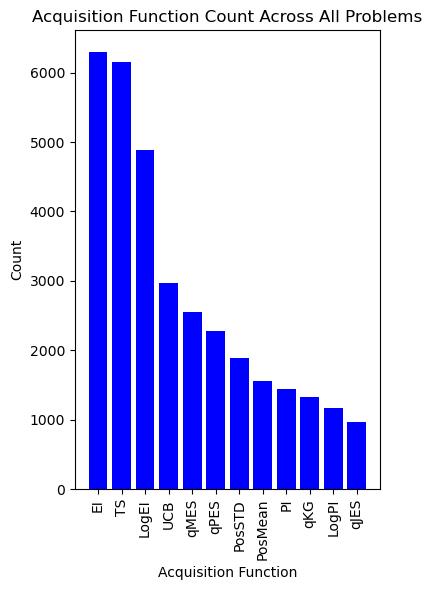

In [24]:
all_af_choices = load_all_af_choices()
# count all AFs
af_count = {}
for problem, problem_choices in all_af_choices.items():
    for i, afs in problem_choices.items():
        for af in afs:
            if af not in af_count:
                af_count[af] = 0
            af_count[af] += 1
# plot the sorted AF count by a bar chart
import matplotlib.pyplot as plt
af_count = dict(sorted(af_count.items(), key=lambda item: item[1], reverse=True))
# make the bars closer to each other
plt.figure(figsize=(4, 6))
plt.bar(af_count.keys(), af_count.values(), width=0.8, color='blue', linewidth=0.7, align='center')
plt.xticks(rotation=90)
plt.xlabel('Acquisition Function')
plt.ylabel('Count')
plt.title('Acquisition Function Count Across All Problems')
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_count.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Dataset-specific frequency

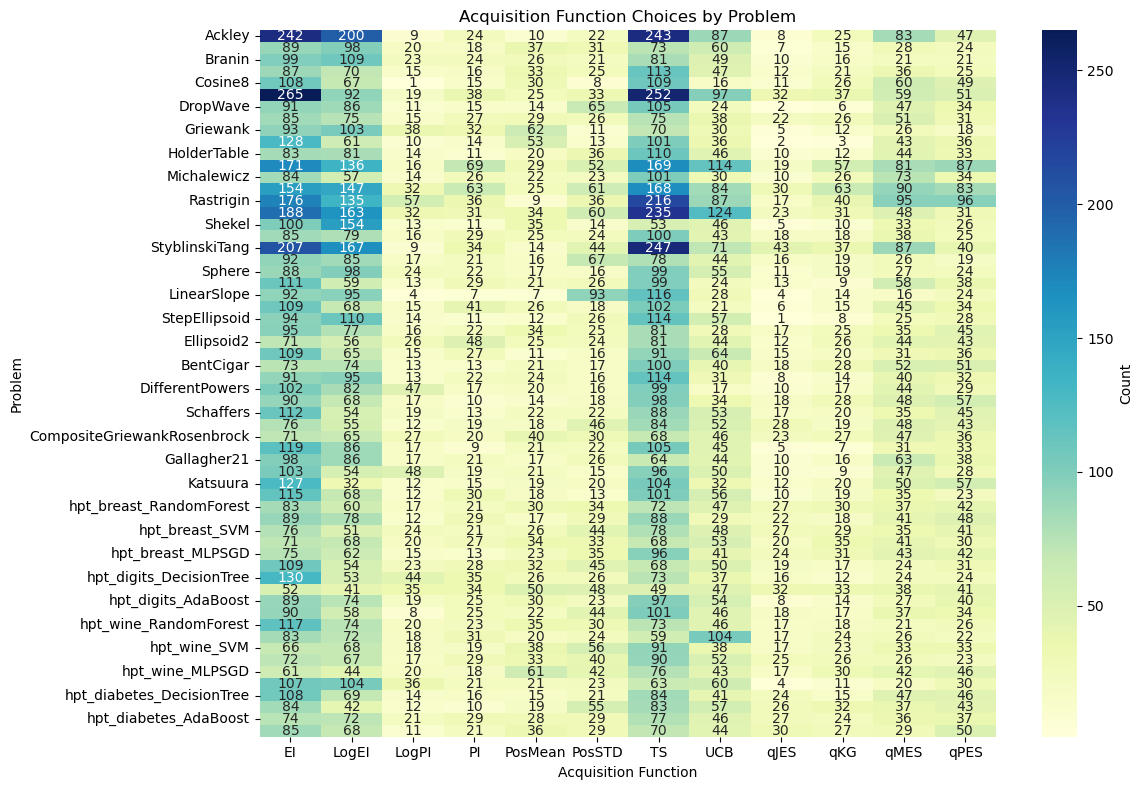

In [ ]:
# Plot the AF choices for each problem by a heatmap
# For each problem, count the number of choices for each AF
# The colors should be based on the count of choices on the same problem
# Create a dataframe where rows are problems and columns are AF choices
import seaborn as sns
import numpy as np
import pandas as pd
problems = list(all_af_choices.keys())
af_count_by_problem = {problem: {af: 0 for af in af_count.keys()} for problem in problems}
for problem, choices in all_af_choices.items():
    for i, afs in choices.items():
        for af in afs:
            af_count_by_problem[problem][af] += 1
af_df = pd.DataFrame(af_count_by_problem).T.fillna(0)
af_df = af_df[sorted(af_df.columns)]
plt.figure(figsize=(12, 8))
sns.heatmap(af_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Count'})
plt.xlabel('Acquisition Function')
plt.ylabel('Problem')
plt.title('Acquisition Function Choices by Problem')
plt.tight_layout()
plt.show()

# Temporal Analysis

## AF choice by iteration

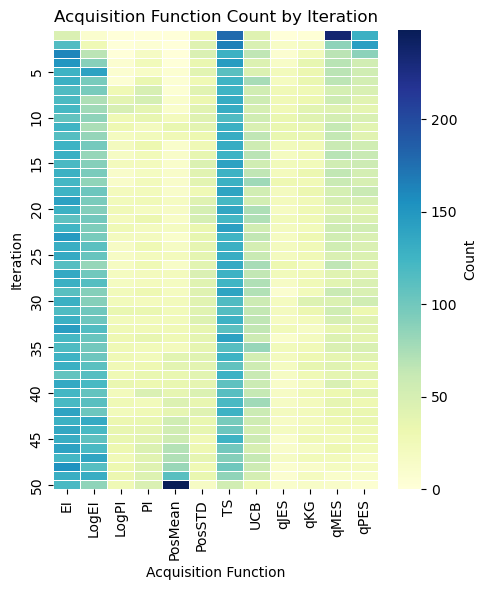

In [35]:
# Count the frequency of each AF per iteration across all problems
# We either have 50 or 100 iterations, depending on the problem, so we will group by 50
# Create a dataframe where rows are iterations and columns are AF choices
# For problems with 100 iterations, we will group them by 50, which means iterations 1 and 2 will be grouped together, 3 and 4, etc.
af_count_by_iteration = {i: {af: 0 for af in af_count.keys()} for i in range(1, 51)}
for problem, choices in all_af_choices.items():
    for afs in choices.values():
        for j, af in enumerate(afs):
            # Group by 50 iterations
            if len(afs) == 50:
                iteration = j + 1
            else:
                # For 100 iterations, we group them by 50
                if j % 2 == 0:  # even index means first of the pair
                    iteration = (j // 2) + 1
            af_count_by_iteration[iteration][af] += 1
af_iter_df = pd.DataFrame(af_count_by_iteration).T.fillna(0)
af_iter_df = af_iter_df[sorted(af_iter_df.columns)]
plt.figure(figsize=(5, 6))
sns.heatmap(af_iter_df, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Count'}, linewidths=0.5)
plt.xlabel('Acquisition Function')
plt.ylabel('Iteration')
plt.yticks(np.arange(4.5, 51.5, 5), np.arange(5, 52, 5))
plt.title('Acquisition Function Count by Iteration')
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_count_by_iteration.pdf", dpi=300, bbox_inches='tight')
plt.show()

## AF choice with switches

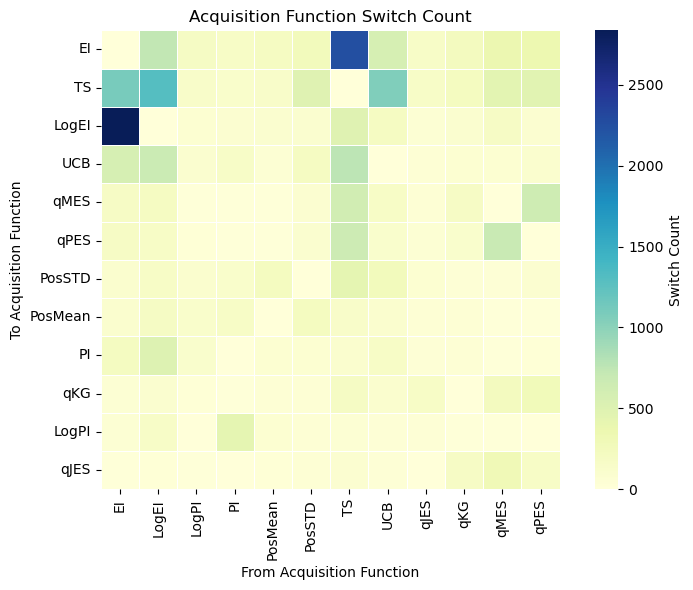

In [49]:
# a heatmap of the number of times the algorithm switched from one AF to another
# For each problem, count the number of switches from one AF to another across all 10 runs
af_switch_count = {af: {af2: 0 for af2 in af_count.keys()} for af in af_count.keys()}
for problem, choices in all_af_choices.items():
    for afs in choices.values():
        for j in range(len(afs) - 1):
            af1 = afs[j]
            af2 = afs[j + 1]
            if af1 != af2:
                af_switch_count[af1][af2] += 1
af_switch_df = pd.DataFrame(af_switch_count).fillna(0)
af_switch_df = af_switch_df[sorted(af_switch_df.columns)]
plt.figure(figsize=(8, 6))
sns.heatmap(af_switch_df, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Switch Count'}, linewidths=0.5, square=True)
plt.xlabel('From Acquisition Function')
plt.ylabel('To Acquisition Function')
plt.title('Acquisition Function Switch Count')
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_switch_count.pdf", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_3501491/235898415.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([switch_counts["50"], switch_counts["100"]], labels=["50 Iterations", "100 Iterations"])


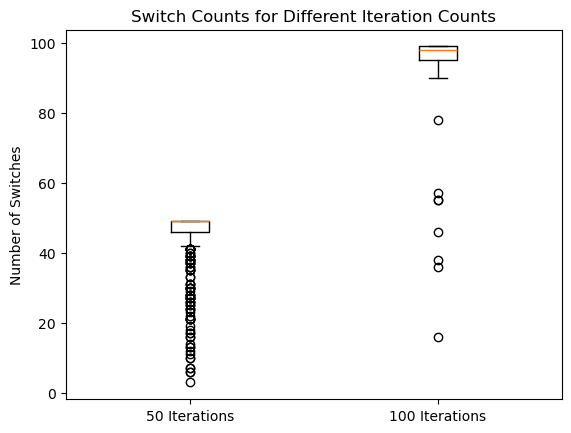

In [38]:
# I want to check how often does the algorithm switch from one AF to another in all_af_choices.
# Make separate counts for runs with 50 iterations and 100 iterations.

switch_counts = {
    "50": [],
    "100": []
}

for all_choices_by_problem in all_af_choices.values():
    for choices in all_choices_by_problem.values():
        switch_count = 0
        for i in range(len(choices) - 1):
            if choices[i] != choices[i + 1]:
                switch_count += 1
        if len(choices) == 50:
            switch_counts["50"].append(switch_count)
        else:
            switch_counts["100"].append(switch_count)
# Now present the two as boxplots
import matplotlib.pyplot as plt

plt.boxplot([switch_counts["50"], switch_counts["100"]], labels=["50 Iterations", "100 Iterations"])
plt.ylabel("Number of Switches")
plt.title("Switch Counts for Different Iteration Counts")
plt.show()

In [39]:
avg_50 = sum(switch_counts["50"]) / len(switch_counts["50"])
avg_100 = sum(switch_counts["100"]) / len(switch_counts["100"])
print(f"Average switch count for 50 iterations: {avg_50:.2f}")
print(f"Average switch count for 100 iterations: {avg_100:.2f}")

Average switch count for 50 iterations: 44.84
Average switch count for 100 iterations: 91.60


# State-conditioned Analysis

## Stagnation vs Improvement

In [62]:
from report import (
    load_results_and_empirical_performance,
    cal_simple_regret,
)
from constants import OBJECTIVE_FUNCTIONS_NAMES
all_raw_results, empirical_optimum = load_results_and_empirical_performance(
    OBJECTIVE_FUNCTIONS_NAMES, 
    ["lmabo"],
)
all_simple_regret = cal_simple_regret(all_raw_results, empirical_optimum)
# Define stagnation and improvement criteria
threshold = 0
# Convert simple regret to stagnation or improvement
# True (improvement) if the simple regret reduces more than the threshold
# False (stagnation) if the simple regret does not reduce more than the threshold
# Do this for each array where an array of N iterations is converted to a list of N binary labels
all_simple_regret_status = {}
for problem in all_simple_regret.keys():
    all_simple_regret_status[problem] = {}
    for i, simple_regret in enumerate(all_simple_regret[problem]["lmabo"]):
        # Convert to stagnation or improvement
        status = [(simple_regret[j] - simple_regret[j + 1]).item() > threshold for j in range(len(simple_regret) - 1)]
        all_simple_regret_status[problem][i] = status

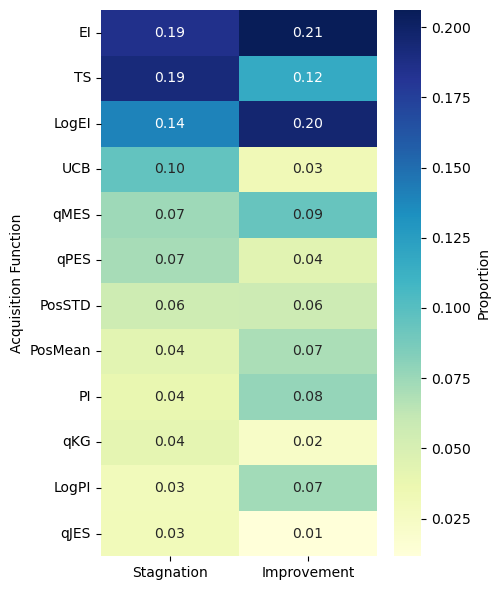

In [67]:
# Now we combine all_simple_regret_status and all_af_choices to count the number of stagnations and improvements for each AF type.
af_combined_status = {af: {"Stagnation": 0, "Improvement": 0} for af in af_count.keys()}
for problem, simple_regret_status_by_problem in all_simple_regret_status.items():
    af_choices_by_problem = all_af_choices[problem]
    for i, status_series in simple_regret_status_by_problem.items():
        af_series = af_choices_by_problem[i]
        for j, status in enumerate(status_series):
                af = af_series[j]
                # Count stagnation and improvement
                if status:
                    af_combined_status[af]["Improvement"] = af_combined_status[af].get("Improvement", 0) + 1
                else:
                    af_combined_status[af]["Stagnation"] = af_combined_status[af].get("Stagnation", 0) + 1

# Create a dataframe for heatmap: rows are AFs, columns are ["Stagnation", "Improvement"], values are proportions across the columns
af_status_df = pd.DataFrame(af_combined_status).T
improvement_total = af_status_df["Improvement"].sum()
stagnation_total = af_status_df["Stagnation"].sum()
af_status_df["Stagnation_prop"] = af_status_df["Stagnation"] / stagnation_total
af_status_df["Improvement_prop"] = af_status_df["Improvement"] / improvement_total
heatmap_df = af_status_df[["Stagnation_prop", "Improvement_prop"]]
heatmap_df = heatmap_df.rename(columns={"Stagnation_prop": "Stagnation", "Improvement_prop": "Improvement"})

plt.figure(figsize=(5, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Proportion'})
plt.ylabel("Acquisition Function")
plt.tight_layout()
plt.savefig(f"{fig_save_path}/af_stagnation_improvement_proportion.pdf", dpi=300, bbox_inches='tight')
plt.show()

## Correlation with GP model parameters

In [25]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def read_params_af_log(log_path):
    # Patterns for extraction
    run_pattern = re.compile(r"RUN (\d+)")
    iter_pattern = re.compile(r"Iter (\d+)\|")
    lengthscale_pattern = re.compile(
        r"Lengthscales: Range \[([0-9.eE+-]+), ([0-9.eE+-]+)\], Mean ([0-9.eE+-]+) \(Std Dev ([0-9.eE+-]+)\)"
    )
    outputscale_pattern = re.compile(r"Outputscale: ([0-9.eE+-]+)")
    shortest_dist_pattern = re.compile(r"Shortest distance: ([0-9.eE+-]+)")
    llm_af_pattern = re.compile(r"^(EI|TS|UCB|LogEI|qPES|qMES|qJES|qKG|PI|LogPI|PosSTD|PosMean):|LLM suggested AF: ([A-Za-z0-9]+)")

    results = []
    current_run = None
    current_iter = None

    with open(log_path, "r") as f:
        for line in f:
            # Detect run
            run_match = run_pattern.match(line)
            if run_match:
                current_run = int(run_match.group(1))
                continue

            # Detect iteration
            iter_match = iter_pattern.match(line)
            if iter_match:
                current_iter = int(iter_match.group(1))
                continue

            # Extract lengthscale
            lengthscale_match = lengthscale_pattern.search(line)
            if lengthscale_match:
                ls_min = float(lengthscale_match.group(1))
                ls_max = float(lengthscale_match.group(2))
                ls_mean = float(lengthscale_match.group(3))
                ls_std = float(lengthscale_match.group(4))
                continue

            # Extract outputscale
            outputscale_match = outputscale_pattern.search(line)
            if outputscale_match:
                outputscale = float(outputscale_match.group(1))
                continue

            # Extract shortest distance
            shortest_dist_match = shortest_dist_pattern.search(line)
            if shortest_dist_match:
                shortest_dist = float(shortest_dist_match.group(1))
                continue

            # Extract AF
            af_match = llm_af_pattern.search(line)
            if af_match:
                af = af_match.group(1) if af_match.group(1) else af_match.group(2)
                # Save only if all fields are present
                if current_run is not None and current_iter is not None:
                    results.append({
                        "run": current_run,
                        "iteration": current_iter,
                        "lengthscale_min": ls_min,
                        "lengthscale_max": ls_max,
                        "lengthscale_mean": ls_mean,
                        "lengthscale_std": ls_std,
                        "outputscale": outputscale,
                        "shortest_distance": shortest_dist,
                        "af": af
                    })
    return pd.DataFrame(results)

# Example: print first 5 entries
log_path = "log/Rosenbrock_lmabo.out"
# log_path = "log/Bukin_lmabo.out"
params_af_df = read_params_af_log(log_path)
# Summarize the frequence of af
af_frequency = params_af_df['af'].value_counts()
print("Frequency of Acquisition Functions:")
print(af_frequency)
print("DF shape: ", params_af_df.shape)
params_af_df.head()

Frequency of Acquisition Functions:
af
TS         240
EI         194
LogEI      163
UCB        125
PosSTD      60
qMES        48
PosMean     34
LogPI       32
qPES        31
qKG         31
PI          31
qJES        23
Name: count, dtype: int64
DF shape:  (1012, 9)


,run,iteration,lengthscale_min,lengthscale_max,lengthscale_mean,lengthscale_std,outputscale,shortest_distance,af
0,0,0,0.803,97.820,46.310,37.493,2.345512,1.747947,qPES
1,0,1,0.803,97.820,46.310,37.493,2.345512,1.717258,qKG
2,0,2,0.931,128.926,55.030,44.857,2.759542,1.636202,UCB
3,0,3,0.846,815.284,315.783,267.722,2.652855,2.083167,EI
4,0,4,0.696,220.689,90.172,68.322,2.462569,1.470775,LogEI


In [21]:
# count number of rows for each run
row_counts = params_af_df['run'].value_counts()
print("Row counts per run:")
print(row_counts)

Row counts per run:
run
2    110
7    101
9    101
0    100
1    100
3    100
5    100
4    100
6    100
8    100
Name: count, dtype: int64


In [23]:
params_af_df[params_af_df["run"]==2]

,run,iteration,lengthscale_min,lengthscale_max,lengthscale_mean,lengthscale_std,outputscale,shortest_distance,af
200,2,99,2.224,6.862,4.484,1.412,3.008120,0.315831,EI
201,2,99,2.224,6.862,4.484,1.412,3.008120,0.315831,TS
202,2,99,2.224,6.862,4.484,1.412,3.008120,0.315831,UCB
203,2,99,2.224,6.862,4.484,1.412,3.008120,0.315831,TS
204,2,99,2.224,6.862,4.484,1.412,3.008120,0.315831,EI
...,...,...,...,...,...,...,...,...,...
305,2,95,2.355,42.284,5.746,8.001,2.523168,0.712965,TS
306,2,96,2.025,129.427,9.185,25.157,2.502845,1.342870,UCB
307,2,97,2.106,377.193,20.641,74.655,2.801527,2.167416,TS
308,2,98,1.429,540.127,78.074,146.008,2.861938,0.993898,EI


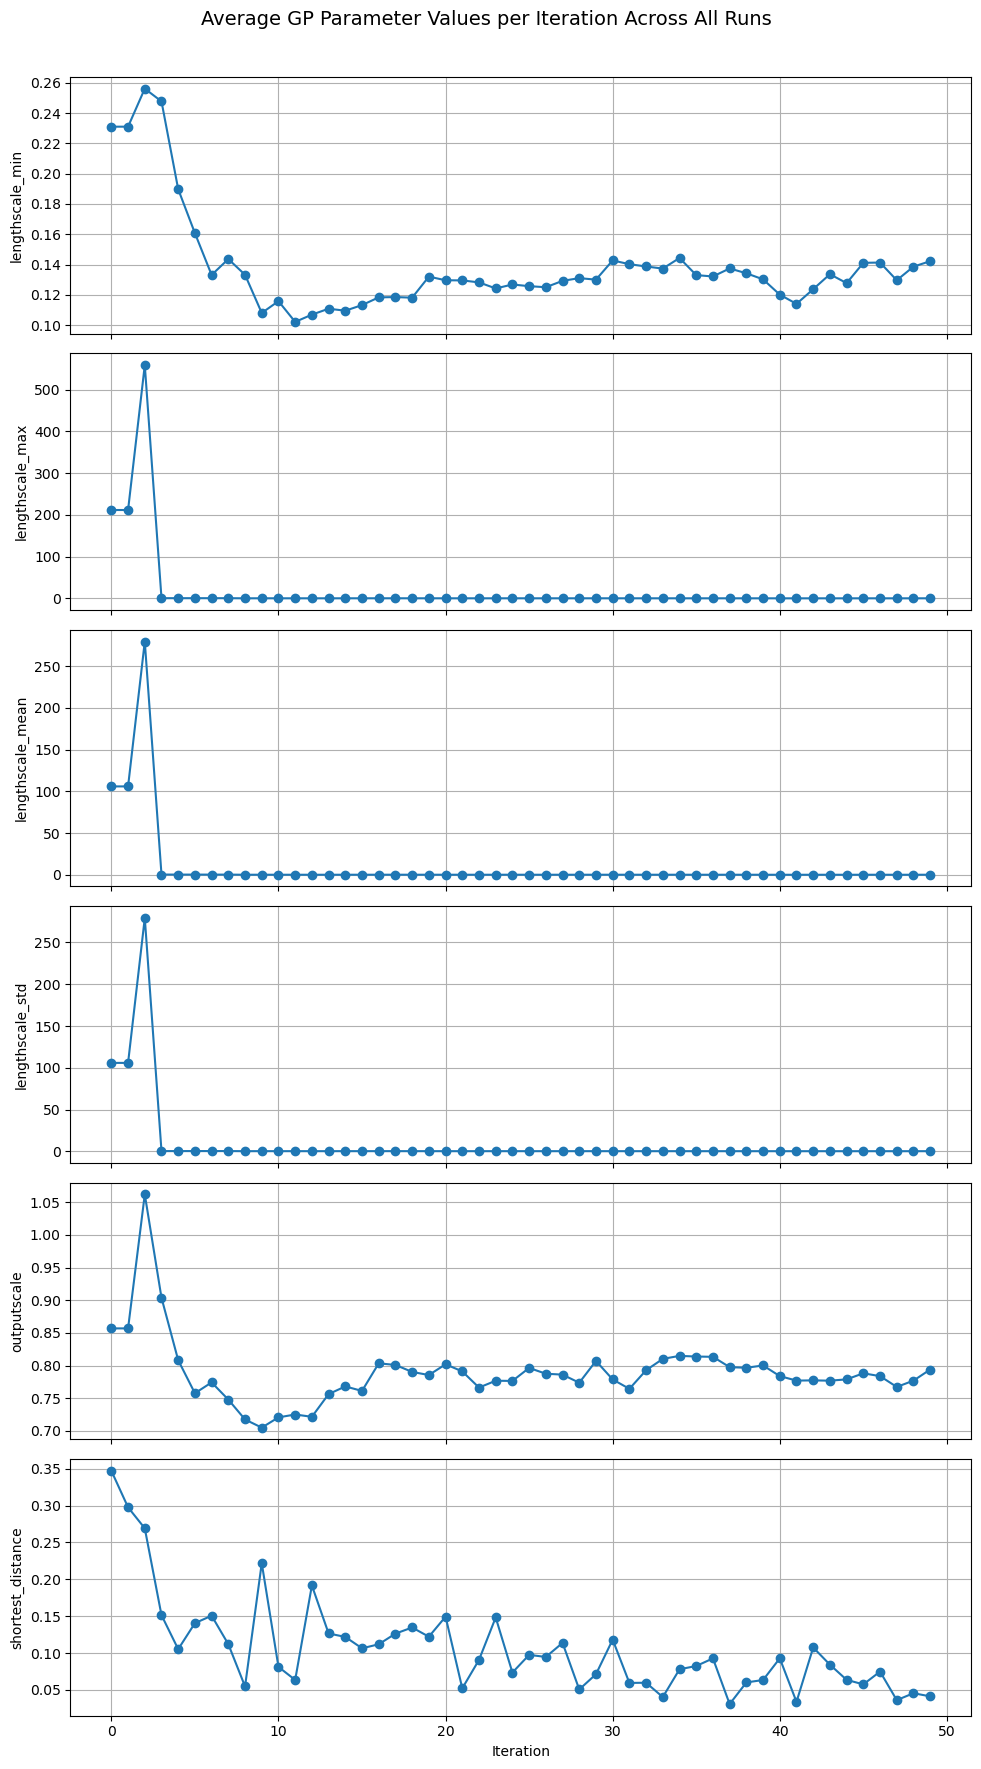

In [12]:
numerical_cols = ['lengthscale_min', 'lengthscale_max', 'lengthscale_mean', 'lengthscale_std', 'outputscale', 'shortest_distance']

avg_by_iter = params_af_df.groupby('iteration')[numerical_cols].mean()

fig, axes = plt.subplots(len(numerical_cols), 1, figsize=(10, 3 * len(numerical_cols)), sharex=True)
for idx, col in enumerate(numerical_cols):
    axes[idx].plot(avg_by_iter.index, avg_by_iter[col], marker='o')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True)
axes[-1].set_xlabel('Iteration')
fig.suptitle('Average GP Parameter Values per Iteration Across All Runs', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [13]:
# aggregate the numerical columns by af
agg_params_af_df = params_af_df.groupby('af')[numerical_cols].agg(['mean']).reset_index()
agg_params_af_df.columns = ['af'] + [f"{col}_{stat}" for col, stat in agg_params_af_df.columns[1:]]
agg_params_af_df

,af,lengthscale_min_mean,lengthscale_max_mean,lengthscale_mean_mean,lengthscale_std_mean,outputscale_mean,shortest_distance_mean
0,EI,0.141077,59.067788,29.604442,29.463327,0.795100,0.105471
1,LogEI,0.138081,0.444435,0.291258,0.153113,0.760247,0.074719
2,LogPI,0.099600,0.531000,0.315400,0.215600,0.774549,0.040361
3,PI,0.140867,0.519800,0.330400,0.189600,0.793131,0.074372
4,PosMean,0.128067,0.397333,0.262533,0.134733,0.736032,0.042846
5,PosSTD,0.141059,0.603412,0.372353,0.231000,0.774725,0.054162
6,TS,0.130964,7.161540,3.646324,3.515259,0.791081,0.128910
7,UCB,0.153274,23.688226,11.920774,11.767484,0.785590,0.075358
8,qJES,0.147000,0.441000,0.294333,0.147000,0.816613,0.105021
9,qKG,0.130250,0.362500,0.246250,0.116000,0.840589,0.181691


In [14]:
explorative_group = ['UCB', 'TS', 'qKG', 'qMES', 'qPES', 'qJES', 'PosSTD']
exploitative_group = ['EI', 'LogEI', 'PI', 'LogPI', 'PosMean']
# get the summary statistics for each group by taking the mean of the columns
explorative_df = agg_params_af_df[agg_params_af_df['af'].isin(explorative_group)]
print("Explorative")
print(explorative_df.mean(axis=0, numeric_only=True))
exploitative_df = agg_params_af_df[agg_params_af_df['af'].isin(exploitative_group)]
print("Exploitative")
print(exploitative_df.mean(axis=0, numeric_only=True))


Explorative
lengthscale_min_mean       0.142961
lengthscale_max_mean      10.203587
lengthscale_mean_mean      5.173317
lengthscale_std_mean       5.030241
outputscale_mean           0.804654
shortest_distance_mean     0.117868
dtype: float64
Exploitative
lengthscale_min_mean       0.129538
lengthscale_max_mean      12.192071
lengthscale_mean_mean      6.160807
lengthscale_std_mean       6.031275
outputscale_mean           0.771812
shortest_distance_mean     0.067554
dtype: float64


NameError: name 'fig_save_path' is not defined

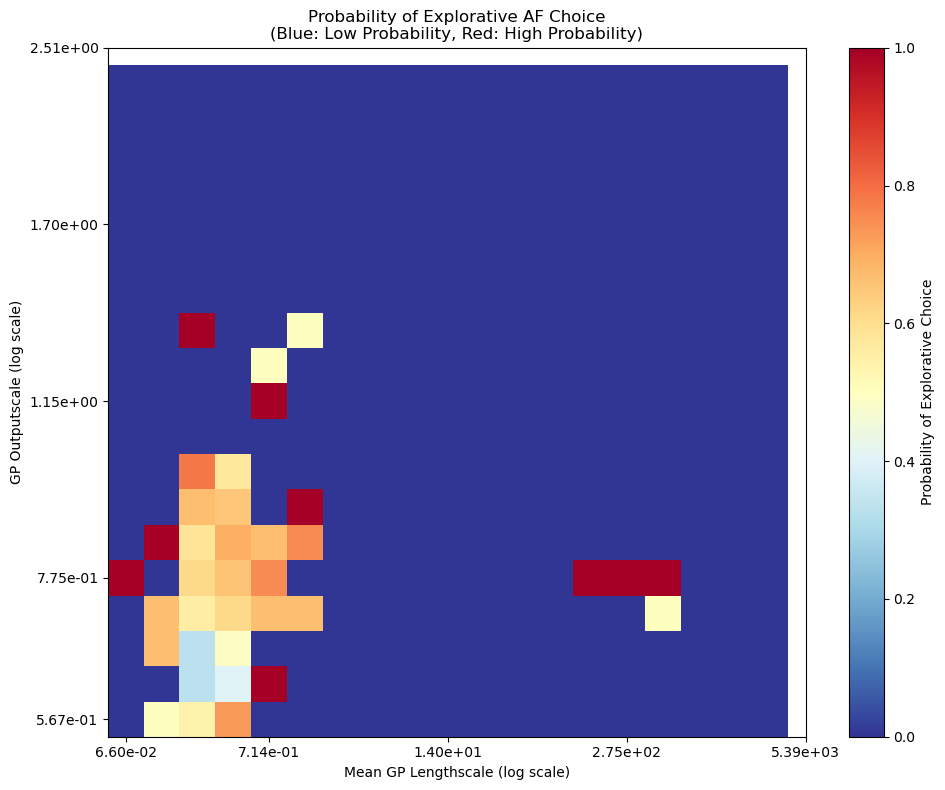

In [18]:
# make a 2D heatmap of lengthscale_mean vs outputscale
# blue if explorative and red if exploitative
# write the code to save the figure as a pdf file
# Create 2D heatmap showing probability of explorative AF choice
# based on lengthscale_mean and outputscale

# Create bins for the 2D grid
n_bins = 20
lengthscale_bins = np.logspace(np.log10(params_af_df['lengthscale_max'].min()), 
                              np.log10(params_af_df['lengthscale_max'].max()), 
                              n_bins)
outputscale_bins = np.logspace(np.log10(params_af_df['outputscale'].min()), 
                              np.log10(params_af_df['outputscale'].max()), 
                              n_bins)

# Create 2D histogram for explorative choices
params_af_df['af_type'] = params_af_df['af'].apply(lambda x: 'explorative' if x in explorative_group else 'exploitative')
explorative_mask = params_af_df['af_type'] == 'explorative'
explorative_hist, _, _ = np.histogram2d(params_af_df[explorative_mask]['lengthscale_max'],
                                       params_af_df[explorative_mask]['outputscale'],
                                       bins=[lengthscale_bins, outputscale_bins])

# Create 2D histogram for all choices
total_hist, _, _ = np.histogram2d(params_af_df['lengthscale_max'],
                                 params_af_df['outputscale'],
                                 bins=[lengthscale_bins, outputscale_bins])

# Calculate probability of explorative choice
prob_explorative = np.divide(explorative_hist, total_hist, 
                           out=np.zeros_like(explorative_hist), 
                           where=total_hist!=0)

# Create the heatmap
plt.figure(figsize=(10, 8))
im = plt.imshow(prob_explorative.T, origin='lower', aspect='auto', 
                cmap='RdYlBu_r', vmin=0, vmax=1)

# Set log scale ticks
x_ticks = np.linspace(0, n_bins-1, 5).astype(int)
y_ticks = np.linspace(0, n_bins-1, 5).astype(int)
plt.xticks(x_ticks, [f'{lengthscale_bins[i]:.2e}' for i in x_ticks])
plt.yticks(y_ticks, [f'{outputscale_bins[i]:.2e}' for i in y_ticks])

plt.xlabel('Mean GP Lengthscale (log scale)')
plt.ylabel('GP Outputscale (log scale)')
plt.title('Probability of Explorative AF Choice\n(Blue: Low Probability, Red: High Probability)')

# Add colorbar
cbar = plt.colorbar(im)
cbar.set_label('Probability of Explorative Choice')

plt.tight_layout()
plt.savefig(f"{fig_save_path}/gp_parameters_explorative_heatmap.pdf", dpi=300, bbox_inches='tight')
plt.show()


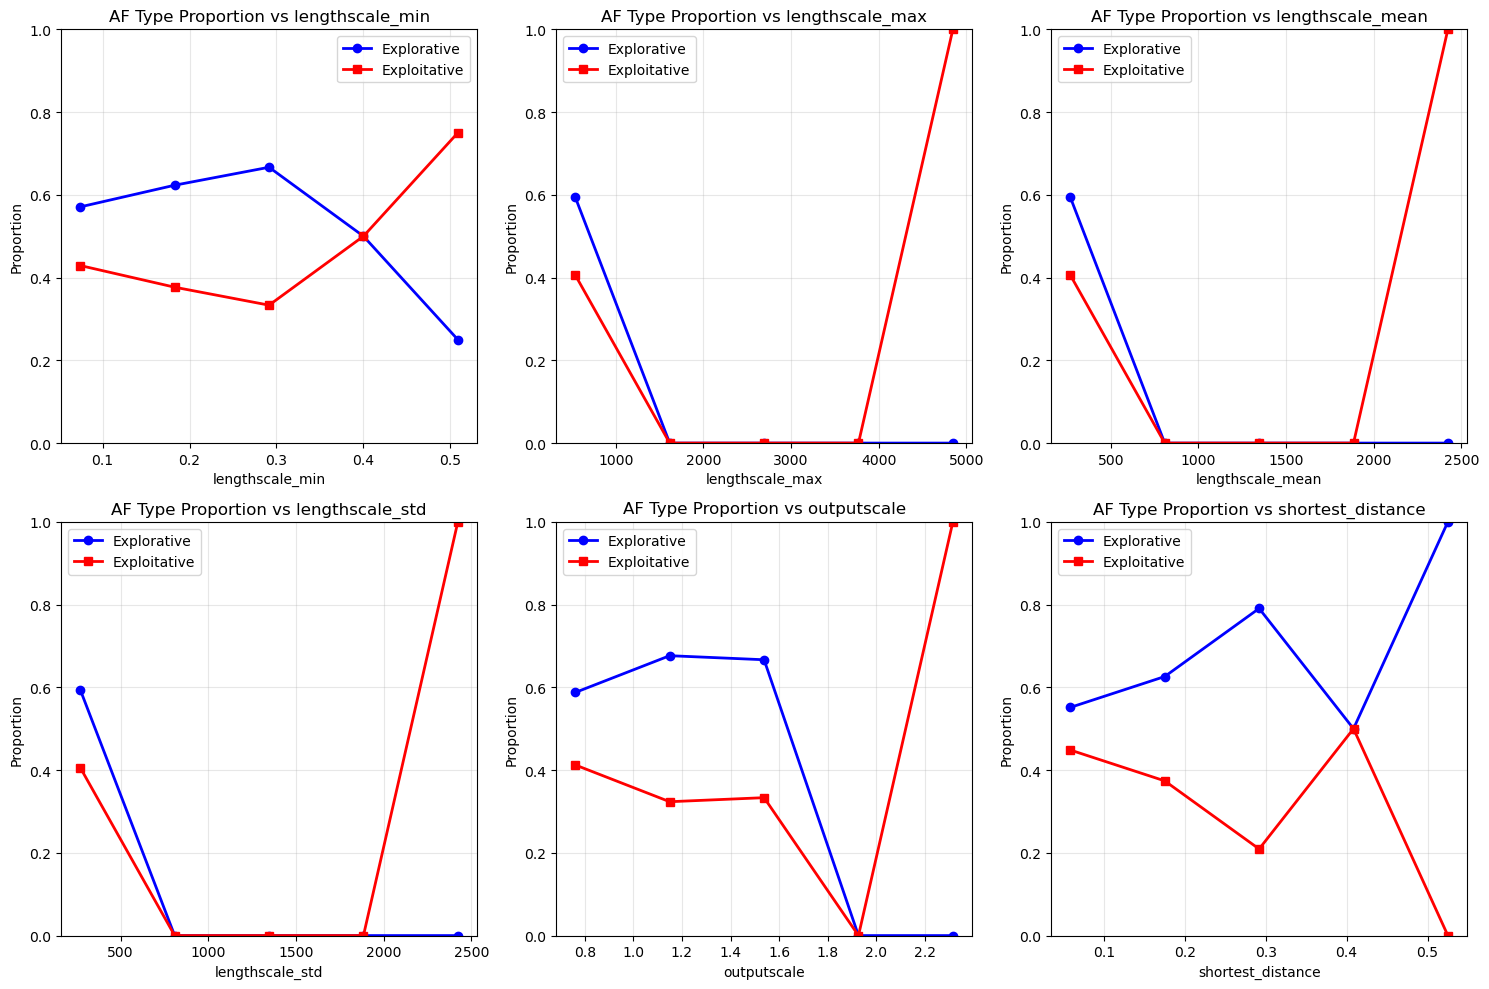

In [17]:
# Create line charts comparing explorative vs exploitative AF proportions across different bins
# Add af_type column if not already present
if 'af_type' not in params_af_df.columns:
    params_af_df['af_type'] = params_af_df['af'].apply(
        lambda x: 'explorative' if x in explorative_group else 'exploitative'
    )

# Parameters to analyze
numerical_cols = ['lengthscale_min', 'lengthscale_max', 'lengthscale_mean', 'lengthscale_std', 'outputscale', 'shortest_distance']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    # Create bins for the parameter
    n_bins = 5
    bins = np.linspace(params_af_df[col].min(), params_af_df[col].max(), n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Calculate proportions for each bin
    explorative_counts = np.zeros(n_bins)
    exploitative_counts = np.zeros(n_bins)
    
    for i in range(n_bins):
        bin_mask = (params_af_df[col] >= bins[i]) & (params_af_df[col] < bins[i+1])
        if i == n_bins - 1:  # Include the last bin's upper edge
            bin_mask = (params_af_df[col] >= bins[i]) & (params_af_df[col] <= bins[i+1])
        
        bin_data = params_af_df[bin_mask]
        total_in_bin = len(bin_data)
        
        if total_in_bin > 0:
            explorative_counts[i] = len(bin_data[bin_data['af_type'] == 'explorative']) / total_in_bin
            exploitative_counts[i] = len(bin_data[bin_data['af_type'] == 'exploitative']) / total_in_bin
    
    # Plot the line chart
    axes[idx].plot(bin_centers, explorative_counts, 'b-o', label='Explorative', linewidth=2, markersize=6)
    axes[idx].plot(bin_centers, exploitative_counts, 'r-s', label='Exploitative', linewidth=2, markersize=6)
    
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Proportion')
    axes[idx].set_title(f'AF Type Proportion vs {col}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(0, 1)

plt.tight_layout()
# plt.savefig(f"{fig_save_path}/af_type_proportion_by_parameters.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Qualitative and Comparative Analysis

## Meta Strategies